In [ ]:
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.callbacks import EarlyStopping
from datetime import datetime
from datetime import date
import matplotlib.dates as mdates

In [ ]:
Sentiment_Scores = pd.read_csv('Sentiment_Scores_Dataset.csv')
combined_data = pd.read_csv('btc_quotes.csv')

In [ ]:
combined_data.head()

,report_dttm,open_price,high_price,low_price,close_price,volume
0,2024-12-21 03:14:56.128,97277.3,97349.0,97257.6,97347.5,72.482
1,2024-12-21 03:10:33.984,97225.0,97315.0,97224.9,97277.3,70.568
2,2024-12-21 03:04:00.768,97220.0,97309.2,97220.0,97225.0,73.444
3,2024-12-21 02:59:38.624,97334.1,97381.7,97220.0,97220.0,72.206
4,2024-12-21 02:55:16.48,97440.0,97441.7,97321.4,97334.1,39.897


In [ ]:
combined_data['date'] = pd.to_datetime(
    combined_data['report_dttm'],
    format='mixed',
    errors='coerce'
).dt.normalize()

Daily_Price = combined_data.groupby('date')['close_price'].mean()

Daily_Price.head()


,close_price
date,
2024-12-20,96085.329375
2024-12-21,97627.431597
2024-12-22,96230.019723
2024-12-23,94731.403819
2024-12-24,95892.147222


In [ ]:
Sentiment_Scores.head()

,publish_dttm,compound,VADER_Sentiment_Scores,BERT_Compound,BERT_Sentiment_Scores
0,2026-04-06 15:47:00,0.9792,1,0.141118,1
1,2026-04-06 15:41:00,0.9132,1,0.103483,1
2,2026-03-26 13:18:00,-0.1326,-1,-0.488784,-1
3,2026-04-06 13:46:00,0.8294,1,0.227587,1
4,2026-03-26 12:23:00,0.7713,1,0.666253,1


In [ ]:
Sentiment_Scores.drop(['VADER_Sentiment_Scores','BERT_Sentiment_Scores'], axis=1, inplace=True)
Sentiment_Scores['date'] = pd.to_datetime(Sentiment_Scores['publish_dttm']).dt.normalize()
Sentiment_Scores.head(5)

,publish_dttm,compound,BERT_Compound,date
0,2026-04-06 15:47:00,0.9792,0.141118,2026-04-06
1,2026-04-06 15:41:00,0.9132,0.103483,2026-04-06
2,2026-03-26 13:18:00,-0.1326,-0.488784,2026-03-26
3,2026-04-06 13:46:00,0.8294,0.227587,2026-04-06
4,2026-03-26 12:23:00,0.7713,0.666253,2026-03-26


In [ ]:
duplicates_count = Sentiment_Scores[Sentiment_Scores['date'].duplicated(keep=False)].shape[0]

print(f"There are {duplicates_count} duplicated date entries in the dataset.")

daily_sentiment = Sentiment_Scores.groupby('date').agg({
    'compound': 'sum',
    'BERT_Compound': 'sum'
}).reset_index()

print(daily_sentiment)

duplicates_count = daily_sentiment[daily_sentiment['date'].duplicated(keep=False)].shape[0]

print(f"There are {duplicates_count} duplicated date entries in the dataset.")

There are 11366 duplicated date entries in the dataset.
          date  compound  BERT_Compound
0   2025-01-01    3.9833       0.913284
1   2025-01-02    4.7556       1.612519
2   2025-01-03    8.2038       0.310516
3   2025-01-06   12.0059       2.148840
4   2025-01-07   15.3863       1.133117
..         ...       ...            ...
462 2026-04-16    7.9679      -0.600045
463 2026-04-17    0.7342      -0.990118
464 2026-04-18    0.8095      -2.592021
465 2026-04-19    0.1822      -2.190352
466 2026-04-20    0.8120      -6.404665

[467 rows x 3 columns]
There are 0 duplicated date entries in the dataset.


In [ ]:
Daily_Price = Daily_Price.reset_index()
merged_df = pd.merge(Daily_Price, daily_sentiment, on='date', how='inner')

In [ ]:
merged_df.shape

(466, 4)

In [ ]:
merged_df.head(5)

,date,close_price,compound,BERT_Compound
0,2025-01-01,93946.659722,3.9833,0.913284
1,2025-01-02,96297.586505,4.7556,1.612519
2,2025-01-03,97246.141319,8.2038,0.310516
3,2025-01-06,100155.027083,12.0059,2.148840
4,2025-01-07,99859.146875,15.3863,1.133117


In [ ]:
Daily_Price = Daily_Price.sort_values('date')

df_train = Daily_Price[Daily_Price['date'] <= '2025-10-31']

val_df = Daily_Price[
    (Daily_Price['date'] > '2025-10-31') &
    (Daily_Price['date'] <= '2025-12-15')
]

df_test = Daily_Price[
    Daily_Price['date'] > '2025-12-15'
]

print("TRAIN:", df_train.shape)
print("VALID:", val_df.shape)
print("TEST :", df_test.shape)

print()

print(
    df_train['date'].min(),
    "→",
    df_train['date'].max()
)

print(
    val_df['date'].min(),
    "→",
    val_df['date'].max()
)

print(
    df_test['date'].min(),
    "→",
    df_test['date'].max()
)

TRAIN: (316, 2)
VALID: (45, 2)
TEST : (125, 2)

2024-12-20 00:00:00 → 2025-10-31 00:00:00
2025-11-01 00:00:00 → 2025-12-15 00:00:00
2025-12-16 00:00:00 → 2026-04-19 00:00:00


In [ ]:
working_data = [df_train, val_df, df_test]
working_data = pd.concat(working_data)

working_data = working_data.reset_index()
working_data['date'] = pd.to_datetime(working_data['date'])
working_data = working_data.set_index('date')

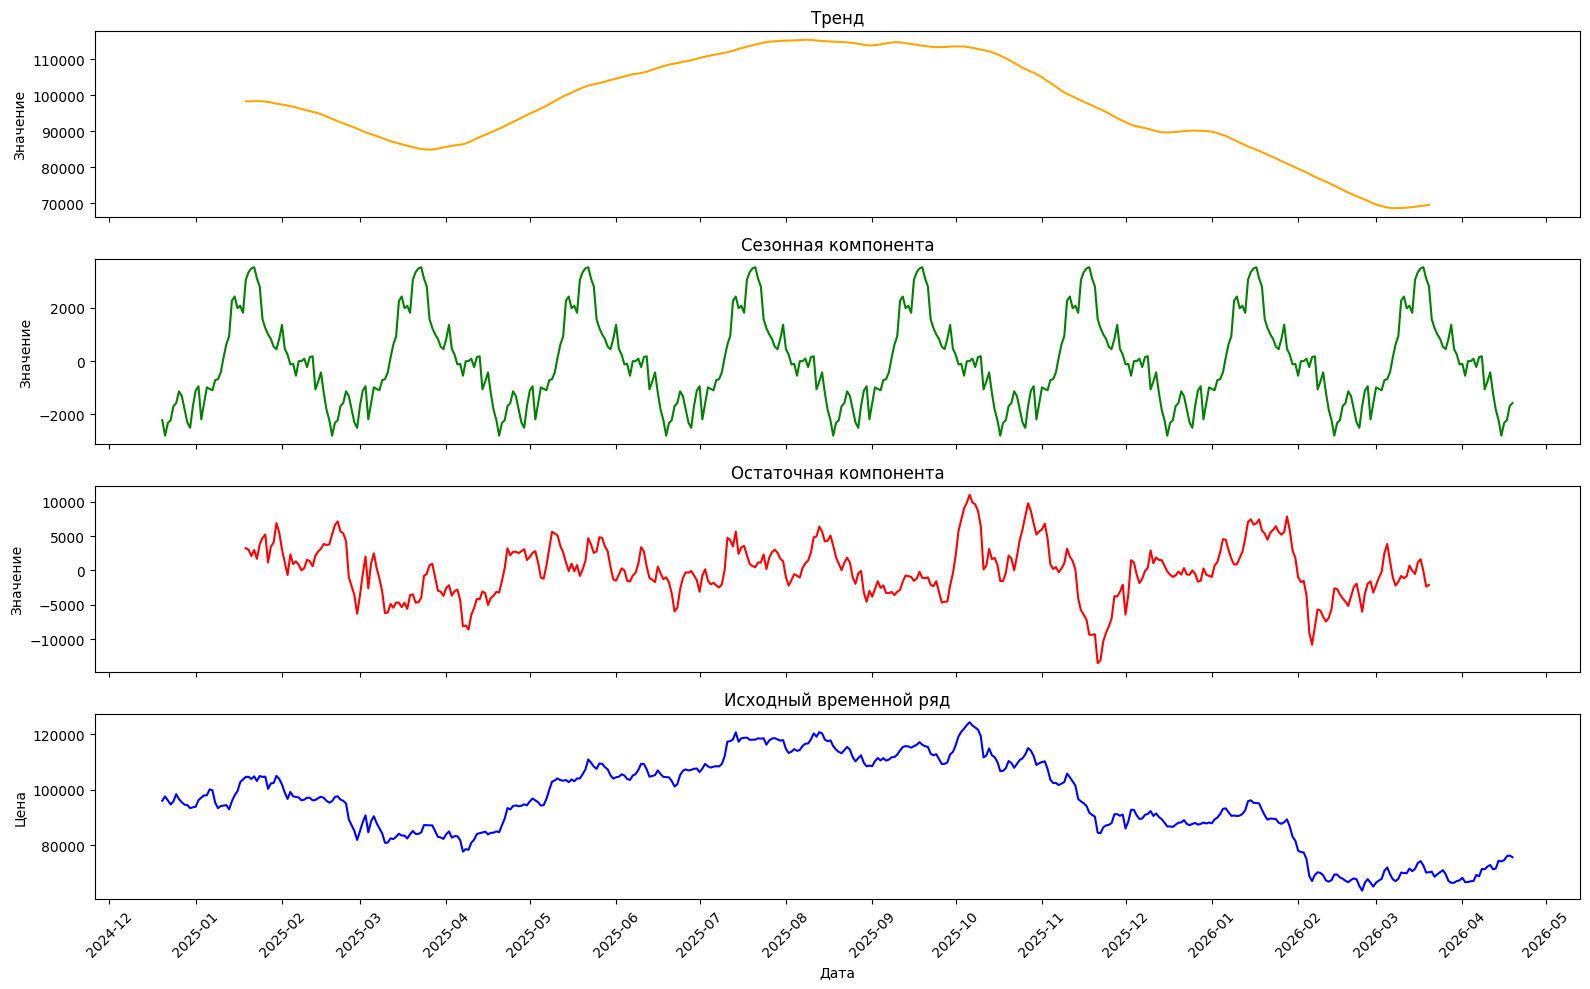

In [ ]:
# Декомпозиция временного ряда
s = sm.tsa.seasonal_decompose(
    working_data['close_price'],
    period=60
)

# Создание фигуры
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# ---------------- TREND ----------------
axes[0].plot(working_data.index, s.trend, color='orange')
axes[0].set_title('Тренд')
axes[0].set_ylabel('Значение')

# ---------------- SEASONAL ----------------
axes[1].plot(working_data.index, s.seasonal, color='green')
axes[1].set_title('Сезонная компонента')
axes[1].set_ylabel('Значение')

# ---------------- RESIDUAL ----------------
axes[2].plot(working_data.index, s.resid, color='red')
axes[2].set_title('Остаточная компонента')
axes[2].set_ylabel('Значение')

# ---------------- OBSERVED ----------------
axes[3].plot(working_data.index, s.observed, color='blue')
axes[3].set_title('Исходный временной ряд')
axes[3].set_ylabel('Цена')
axes[3].set_xlabel('Дата')

# Форматирование дат
axes[3].xaxis.set_major_locator(mdates.MonthLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df_train = working_data[:-170]
val_df = working_data[-170:-125]
df_test = working_data[-125:]

In [ ]:
print(len(df_train), len(df_test), len(val_df))

316 125 45


In [ ]:
test_dates = df_test.reset_index()['date'].copy()
train_dates = df_train.reset_index()['date'].copy()
val_dates = val_df.reset_index()['date'].copy()

In [ ]:
def create_lookback(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

In [ ]:
df_train = df_train.reset_index(drop=True).drop(columns=['index'])
df_test = df_test.reset_index(drop=True).drop(columns=['index'])
val_df = val_df.reset_index(drop=True).drop(columns=['index'])

# Модель на основе ценовых данных

In [ ]:
training_set = df_train.values
training_set = np.reshape(training_set, (len(training_set), 1))
test_set = df_test.values
test_set = np.reshape(test_set, (len(test_set), 1))
val_set = val_df.values
val_set = np.reshape(val_set, (len(val_set), 1))

scaler = MinMaxScaler()
training_set = scaler.fit_transform(training_set)
val_set = scaler.transform(val_set)
test_set = scaler.transform(test_set)

look_back = 5
X_train, Y_train = create_lookback(training_set, look_back)
X_test, Y_test = create_lookback(test_set, look_back)
X_val, Y_val = create_lookback(val_set, look_back)

X_train = np.reshape(X_train, (len(X_train), 1, X_train.shape[1]))
X_test = np.reshape(X_test, (len(X_test), 1, X_test.shape[1]))
X_val = np.reshape(X_val, (len(X_val), 1, X_val.shape[1]))

In [ ]:
model = Sequential()
model.add(LSTM(32, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, shuffle=False,
                    validation_data=(X_val, Y_val),
                    callbacks = [EarlyStopping(monitor='val_loss', min_delta=5e-5, patience=20, verbose=1)])

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.3268 - val_loss: 0.0940
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2712 - val_loss: 0.0690
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2108 - val_loss: 0.0440
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1435 - val_loss: 0.0213
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0755 - val_loss: 0.0071
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0244 - val_loss: 0.0090
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0079 - val_loss: 0.0214
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114 - val_loss: 0.0230
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0109 - val_loss: 0.0167
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0096 - val_loss: 0.0134
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0087 - val_loss: 0.0130
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [ ]:
prediction = model.predict(X_test)
prediction_inverse = scaler.inverse_transform(prediction)
Y_test_inverse = scaler.inverse_transform(Y_test.reshape(-1, 1))
prediction2_inverse = prediction_inverse[:, 0]
Y_test2_inverse = Y_test_inverse[:, 0]

RMSE = sqrt(mean_squared_error(Y_test2_inverse,prediction2_inverse))
print('Test RMSE: %.3f' % RMSE)

MAE = mean_absolute_error(Y_test2_inverse,prediction2_inverse)
print('Test MAE: %.3f' % MAE)

r2 = r2_score(Y_test2_inverse,prediction2_inverse)
print('Test R^2: %.3f' % r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Test RMSE: 7145.971
Test MAE: 6099.614
Test R^2: 0.496


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


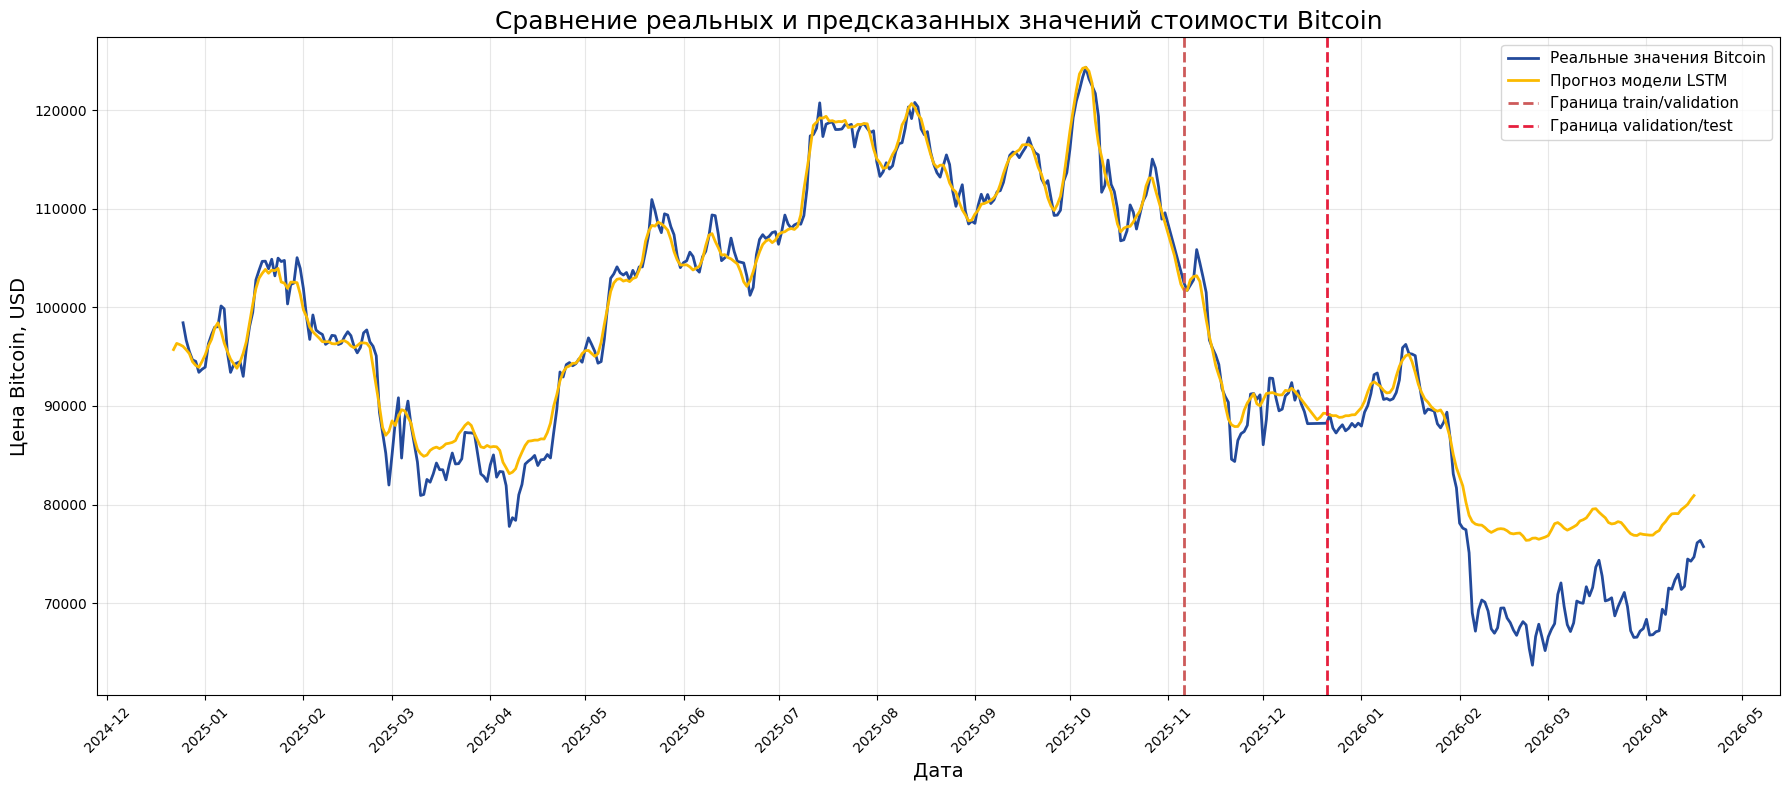

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

train_prediction = model.predict(X_train)

train_prediction_inverse = scaler.inverse_transform(
    train_prediction.reshape(-1, 1)
)[:, 0]

Y_train_inverse = scaler.inverse_transform(
    Y_train.reshape(-1, 1)
)[:, 0]


val_prediction = model.predict(X_val)

val_prediction_inverse = scaler.inverse_transform(
    val_prediction.reshape(-1, 1)
)[:, 0]

Y_val_inverse = scaler.inverse_transform(
    Y_val.reshape(-1, 1)
)[:, 0]

test_prediction = model.predict(X_test)

test_prediction_inverse = scaler.inverse_transform(
    test_prediction.reshape(-1, 1)
)[:, 0]

Y_test_inverse = scaler.inverse_transform(
    Y_test.reshape(-1, 1)
)[:, 0]

train_dates_plot = pd.to_datetime(
    train_dates.iloc[look_back:]
).reset_index(drop=True)

val_dates_plot = pd.to_datetime(
    val_dates.iloc[look_back:]
).reset_index(drop=True)

test_dates_plot = pd.to_datetime(
    test_dates.iloc[look_back:]
).reset_index(drop=True)

min_train = min(
    len(train_dates_plot),
    len(Y_train_inverse),
    len(train_prediction_inverse)
)

train_dates_plot = train_dates_plot[:min_train]

Y_train_inverse = Y_train_inverse[:min_train]

train_prediction_inverse = train_prediction_inverse[:min_train]


min_val = min(
    len(val_dates_plot),
    len(Y_val_inverse),
    len(val_prediction_inverse)
)

val_dates_plot = val_dates_plot[:min_val]

Y_val_inverse = Y_val_inverse[:min_val]

val_prediction_inverse = val_prediction_inverse[:min_val]

min_test = min(
    len(test_dates_plot),
    len(Y_test_inverse),
    len(test_prediction_inverse)
)

test_dates_plot = test_dates_plot[:min_test]

Y_test_inverse = Y_test_inverse[:min_test]

test_prediction_inverse = test_prediction_inverse[:min_test]

all_real_dates = pd.concat([
    train_dates_plot,
    val_dates_plot,
    test_dates_plot
])

all_real_values = np.concatenate([
    Y_train_inverse,
    Y_val_inverse,
    Y_test_inverse
])


all_pred_dates = pd.concat([
    train_dates_plot,
    val_dates_plot,
    test_dates_plot
])

all_pred_values_lstm = np.concatenate([
    train_prediction_inverse,
    val_prediction_inverse,
    test_prediction_inverse
])


plt.figure(figsize=(18, 8))


plt.plot(
    all_real_dates,
    all_real_values,
    label='Реальные значения Bitcoin',
    color='#234A9B',
    linewidth=2
)

plt.plot(
    all_pred_dates,
    all_pred_values_lstm,
    label='Прогноз модели LSTM',
    color='#FBBA00',
    linewidth=2
)

plt.axvline(
    x=val_dates_plot.iloc[0],
    color='#CD5A5A',
    linestyle='--',
    linewidth=2,
    label='Граница train/validation'
)

plt.axvline(
    x=test_dates_plot.iloc[0],
    color='#E61F3D',
    linestyle='--',
    linewidth=2,
    label='Граница validation/test'
)

plt.title('Сравнение реальных и предсказанных значений стоимости Bitcoin',fontsize=18)
plt.xlabel('Дата',  fontsize=14)
plt.ylabel('Цена Bitcoin, USD', fontsize=14)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

train_prediction_inverse_lstm = train_prediction_inverse
val_prediction_inverse_lstm = val_prediction_inverse
test_prediction_inverse_lstm = test_prediction_inverse

In [ ]:
print(len(all_pred_dates))
print(len(all_pred_values_lstm))

471
471


# VADER

In [ ]:
df_vader = merged_df.drop(columns=['BERT_Compound'])

df_vader_train = df_vader[:-170]
val_vader_df = df_vader[-170:-125]
df_vader_test = df_vader[-125:]

In [ ]:
def create_lookback(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), :]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

In [ ]:
training_set_vader = df_vader_train.iloc[:, 1:].values
test_set_vader = df_vader_test.iloc[:, 1:].values
val_set_vader = val_vader_df.iloc[:, 1:].values

scaler = MinMaxScaler(feature_range=(0, 1))
training_set_vader = scaler.fit_transform(training_set_vader)
test_set_vader = scaler.transform(test_set_vader)
val_set_vader = scaler.transform(val_set_vader)

look_back = 5
X_train_vader, Y_train_vader = create_lookback(training_set_vader, look_back)
X_test_vader, Y_test_vader = create_lookback(test_set_vader, look_back)
X_val_vader, Y_val_vader = create_lookback(val_set_vader, look_back)
print(X_train_vader.shape)
print(X_test_vader.shape)

X_train_vader = np.reshape(X_train_vader, (X_train_vader.shape[0], X_train_vader.shape[1], 2))
X_test_vader = np.reshape(X_test_vader, (X_test_vader.shape[0], X_test_vader.shape[1], 2))
X_val_vader = np.reshape(X_val_vader, (X_val_vader.shape[0], X_val_vader.shape[1], 2))

(291, 5, 2)
(120, 5, 2)


In [ ]:
print(X_train_vader.shape)
print(X_test_vader.shape)

(291, 5, 2)
(120, 5, 2)


In [ ]:
model_vader = Sequential()
model_vader.add(LSTM(32, return_sequences=True, input_shape=(X_train_vader.shape[1], X_train_vader.shape[2])))
model_vader.add(LSTM(32))
model_vader.add(Dense(1))

model_vader.compile(loss='mean_squared_error', optimizer='adam')
history_vader = model_vader.fit(X_train_vader, Y_train_vader, epochs=50, batch_size=32, shuffle=False,
                                validation_data=(X_val_vader, Y_val_vader),
                                callbacks=[EarlyStopping(monitor='val_loss', min_delta=5e-5, patience=20, verbose=1)])

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.3025 - val_loss: 0.0505
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1032 - val_loss: 0.0067
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0094 - val_loss: 0.0561
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0265 - val_loss: 0.0289
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0184 - val_loss: 0.0139
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0120 - val_loss: 0.0200
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0109 - val_loss: 0.0213
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0108 - val_loss: 0.0150
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0089 - val_loss: 0.0139
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0078 - val_loss: 0.0130
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0072 - val_loss: 0.0109
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [ ]:
predicted_stock_price = model_vader.predict(X_test_vader)

prediction_with_sentiment = np.concatenate((predicted_stock_price, X_test_vader[:, -1, 1].reshape(-1, 1)),axis=1)
prediction_inverse = scaler.inverse_transform(prediction_with_sentiment)
prediction2_inverse = prediction_inverse[:, 0]
real_with_sentiment = np.concatenate((Y_test_vader.reshape(-1, 1), X_test_vader[:, -1, 1].reshape(-1, 1)),axis=1)

Y_test_inverse = scaler.inverse_transform(real_with_sentiment)

Y_test2_inverse = Y_test_inverse[:, 0]

RMSE = sqrt(mean_squared_error(Y_test2_inverse, prediction2_inverse))

print('Test RMSE: %.3f' % RMSE)

MAE = mean_absolute_error(Y_test2_inverse, prediction2_inverse)

print('Test MAE: %.3f' % MAE)

r2 = r2_score(Y_test2_inverse, prediction2_inverse)

print('Test R^2: %.3f' % r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Test RMSE: 5562.905
Test MAE: 4760.730
Test R^2: 0.695


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


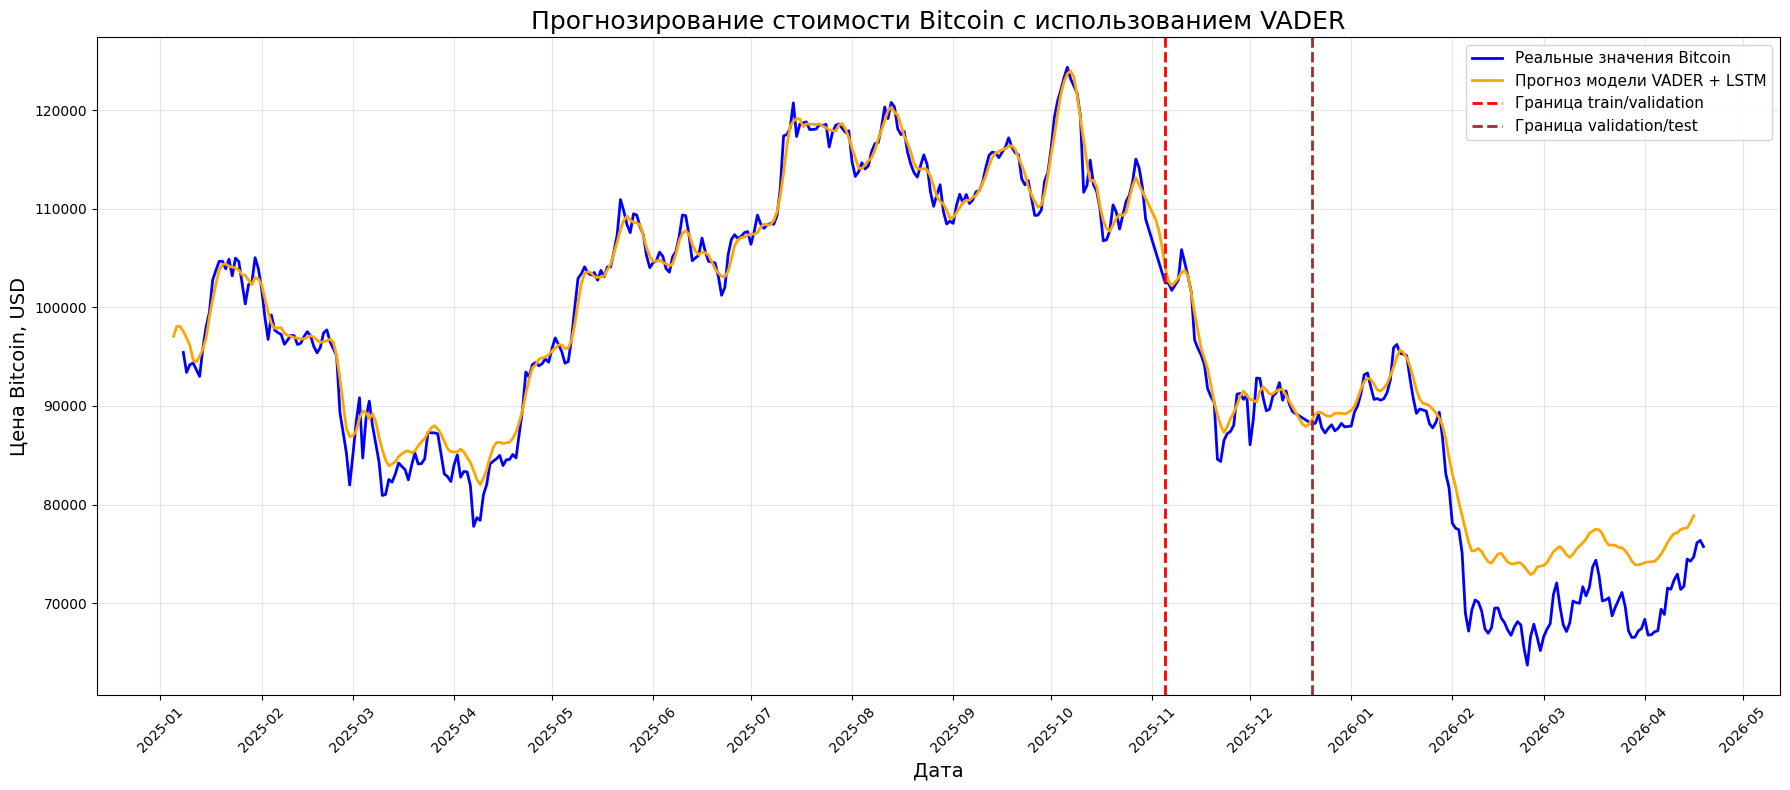

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

train_prediction_vader = model_vader.predict(X_train_vader)
train_full = np.concatenate((train_prediction_vader, X_train_vader[:, -1, 1].reshape(-1, 1)), axis=1)
train_prediction_inverse = scaler.inverse_transform(train_full)[:, 0]

train_real_full = np.concatenate((Y_train_vader.reshape(-1, 1), X_train_vader[:, -1, 1].reshape(-1, 1)),axis=1)
Y_train_inverse = scaler.inverse_transform(train_real_full)[:, 0]

val_prediction_vader = model_vader.predict(X_val_vader)
val_full = np.concatenate((val_prediction_vader, X_val_vader[:, -1, 1].reshape(-1, 1)), axis=1)
val_prediction_inverse = scaler.inverse_transform(val_full)[:, 0]
val_real_full = np.concatenate((Y_val_vader.reshape(-1, 1), X_val_vader[:, -1, 1].reshape(-1, 1)), axis=1)
Y_val_inverse = scaler.inverse_transform(val_real_full)[:, 0]

test_prediction_vader = model_vader.predict(X_test_vader)
test_full = np.concatenate((test_prediction_vader, X_test_vader[:, -1, 1].reshape(-1, 1)),axis=1)
test_prediction_inverse = scaler.inverse_transform(test_full)[:, 0]


test_real_full = np.concatenate((Y_test_vader.reshape(-1, 1), X_test_vader[:, -1, 1].reshape(-1, 1) ), axis=1)

Y_test_inverse = scaler.inverse_transform(test_real_full)[:, 0]

train_dates_plot = pd.to_datetime(df_vader_train['date'].iloc[look_back:]).reset_index(drop=True)

val_dates_plot = pd.to_datetime(val_vader_df['date'].iloc[look_back:]).reset_index(drop=True)

test_dates_plot = pd.to_datetime(df_vader_test['date'].iloc[look_back:]).reset_index(drop=True)

min_train = min(len(train_dates_plot), len(Y_train_inverse), len(train_prediction_inverse))

train_dates_plot = train_dates_plot[:min_train]
Y_train_inverse = Y_train_inverse[:min_train]
train_prediction_inverse = train_prediction_inverse[:min_train]


min_val = min(len(val_dates_plot), len(Y_val_inverse), len(val_prediction_inverse))

val_dates_plot = val_dates_plot[:min_val]
Y_val_inverse = Y_val_inverse[:min_val]
val_prediction_inverse = val_prediction_inverse[:min_val]

min_test = min(len(test_dates_plot), len(Y_test_inverse), len(test_prediction_inverse))

test_dates_plot = test_dates_plot[:min_test]
Y_test_inverse = Y_test_inverse[:min_test]
test_prediction_inverse = test_prediction_inverse[:min_test]


all_real_dates = pd.concat([
    train_dates_plot,
    val_dates_plot,
    test_dates_plot
])

all_real_values = np.concatenate([
    Y_train_inverse,
    Y_val_inverse,
    Y_test_inverse
])

# -----------------------------

all_pred_dates = pd.concat([
    train_dates_plot,
    val_dates_plot,
    test_dates_plot
])

all_pred_values_vader = np.concatenate([
    train_prediction_inverse,
    val_prediction_inverse,
    test_prediction_inverse
])

plt.figure(figsize=(18, 8))

# Реальные значения

plt.plot(
    all_real_dates,
    all_real_values,
    label='Реальные значения Bitcoin',
    color='blue',
    linewidth=2
)

# Предсказания

plt.plot(
    all_pred_dates,
    all_pred_values_vader,
    label='Прогноз модели VADER + LSTM',
    color='orange',
    linewidth=2
)
# =====================================================
# ГРАНИЦЫ ВЫБОРОК
# =====================================================

plt.axvline(
    x=val_dates_plot.iloc[0],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Граница train/validation'
)

plt.axvline(
    x=test_dates_plot.iloc[0],
    color='brown',
    linestyle='--',
    linewidth=2,
    label='Граница validation/test'
)

# =====================================================
# ОФОРМЛЕНИЕ
# =====================================================

plt.title('Прогнозирование стоимости Bitcoin с использованием VADER', fontsize=18)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена Bitcoin, USD',fontsize=14)

# Форматирование оси X

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

train_prediction_inverse_vader = train_prediction_inverse
val_prediction_inverse_vader = val_prediction_inverse
test_prediction_inverse_vader = test_prediction_inverse

# FinBERT

In [ ]:
df_bert = merged_df.drop(columns=['compound'])


In [ ]:
df_bert_train = df_vader[:-170]
val_bert_df = df_vader[-170:-125]
df_bert_test = df_vader[-125:]

In [ ]:
training_set_bert = df_bert_train.iloc[:, 1:].values
test_set_bert = df_bert_test.iloc[:, 1:].values

scaler = MinMaxScaler(feature_range=(0, 1))
training_set_bert = scaler.fit_transform(training_set_bert)
test_set_bert = scaler.transform(test_set_bert)

look_back = 1
X_train_bert, Y_train_bert = create_lookback(training_set_bert, look_back)
X_test_bert, Y_test_bert = create_lookback(test_set_bert, look_back)
print(X_train_bert.shape)
print(X_test_bert.shape)

X_train_bert = np.reshape(X_train_bert, (X_train_bert.shape[0], X_train_bert.shape[1], 2))
X_test_bert = np.reshape(X_test_bert, (X_test_bert.shape[0], X_test_bert.shape[1], 2))


(295, 1, 2)
(124, 1, 2)


In [ ]:
training_set_bert = df_bert_train.iloc[:, 1:].values
test_set_bert = df_bert_test.iloc[:, 1:].values
val_set_bert = val_bert_df.iloc[:, 1:].values

scaler = MinMaxScaler(feature_range=(0, 1))
training_set_bert = scaler.fit_transform(training_set_bert)
test_set_bert = scaler.transform(test_set_bert)
val_set_bert = scaler.transform(val_set_bert)

look_back = 5
X_train_bert, Y_train_bert = create_lookback(training_set_bert, look_back)
X_test_bert, Y_test_bert = create_lookback(test_set_bert, look_back)
X_val_bert, Y_val_bert = create_lookback(val_set_bert, look_back)
print(X_train_bert.shape)
print(X_test_bert.shape)

X_train_bert = np.reshape(X_train_bert, (X_train_bert.shape[0], X_train_bert.shape[1], 2))
X_test_bert = np.reshape(X_test_bert, (X_test_bert.shape[0], X_test_bert.shape[1], 2))
X_val_bert = np.reshape(X_val_bert, (X_val_bert.shape[0], X_val_bert.shape[1], 2))

(291, 5, 2)
(120, 5, 2)


In [ ]:
print(X_train_bert.shape)
print(X_test_bert.shape)

(291, 5, 2)
(120, 5, 2)


In [ ]:
model_bert = Sequential()
model_bert.add(LSTM(32, return_sequences=True, input_shape=(X_train_bert.shape[1], X_train_bert.shape[2])))  # Input shape: (look_back, number of features)
model_bert.add(LSTM(32))
model_bert.add(Dense(1))

model_bert.compile(loss='mean_squared_error', optimizer='adam')
history_bert = model_bert.fit(X_train_bert, Y_train_bert, epochs=50, batch_size=32, shuffle=False,
                                validation_data=(X_val_bert, Y_val_bert),
                                callbacks=[EarlyStopping(monitor='val_loss', min_delta=5e-5, patience=20, verbose=1)])


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.2319 - val_loss: 0.0291
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0595 - val_loss: 0.0144
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0142 - val_loss: 0.0566
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0244 - val_loss: 0.0241
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0172 - val_loss: 0.0154
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0115 - val_loss: 0.0207
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0111 - val_loss: 0.0189
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0101 - val_loss: 0.0135
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0080 - val_loss: 0.0125
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0070 - val_loss: 0.0108
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0063 - val_loss: 0.0090
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [ ]:
predicted_stock_price = model_bert.predict(X_test_bert)

predicted_stock_price = scaler.inverse_transform(np.hstack((predicted_stock_price, X_test_bert[:, 0, 1:].reshape(-1, 1))))

predicted_stock_price = predicted_stock_price[:, 0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [ ]:
predicted_stock_price = model_bert.predict(X_test_bert)
prediction_with_sentiment = np.concatenate((predicted_stock_price, X_test_bert[:, -1, 1].reshape(-1, 1)), axis=1)
prediction_inverse = scaler.inverse_transform(prediction_with_sentiment)
prediction2_inverse = prediction_inverse[:, 0]
real_with_sentiment = np.concatenate((Y_test_bert.reshape(-1, 1), X_test_bert[:, -1, 1].reshape(-1, 1)),axis=1)
Y_test_inverse = scaler.inverse_transform(real_with_sentiment)
Y_test2_inverse = Y_test_inverse[:, 0]

RMSE = sqrt(mean_squared_error(Y_test2_inverse, prediction2_inverse))
print('Test RMSE: %.3f' % RMSE)

MAE = mean_absolute_error(Y_test2_inverse, prediction2_inverse)
print('Test MAE: %.3f' % MAE)

r2 = r2_score(Y_test2_inverse, prediction2_inverse)
print('Test R^2: %.3f' % r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Test RMSE: 4566.396
Test MAE: 3770.297
Test R^2: 0.794


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


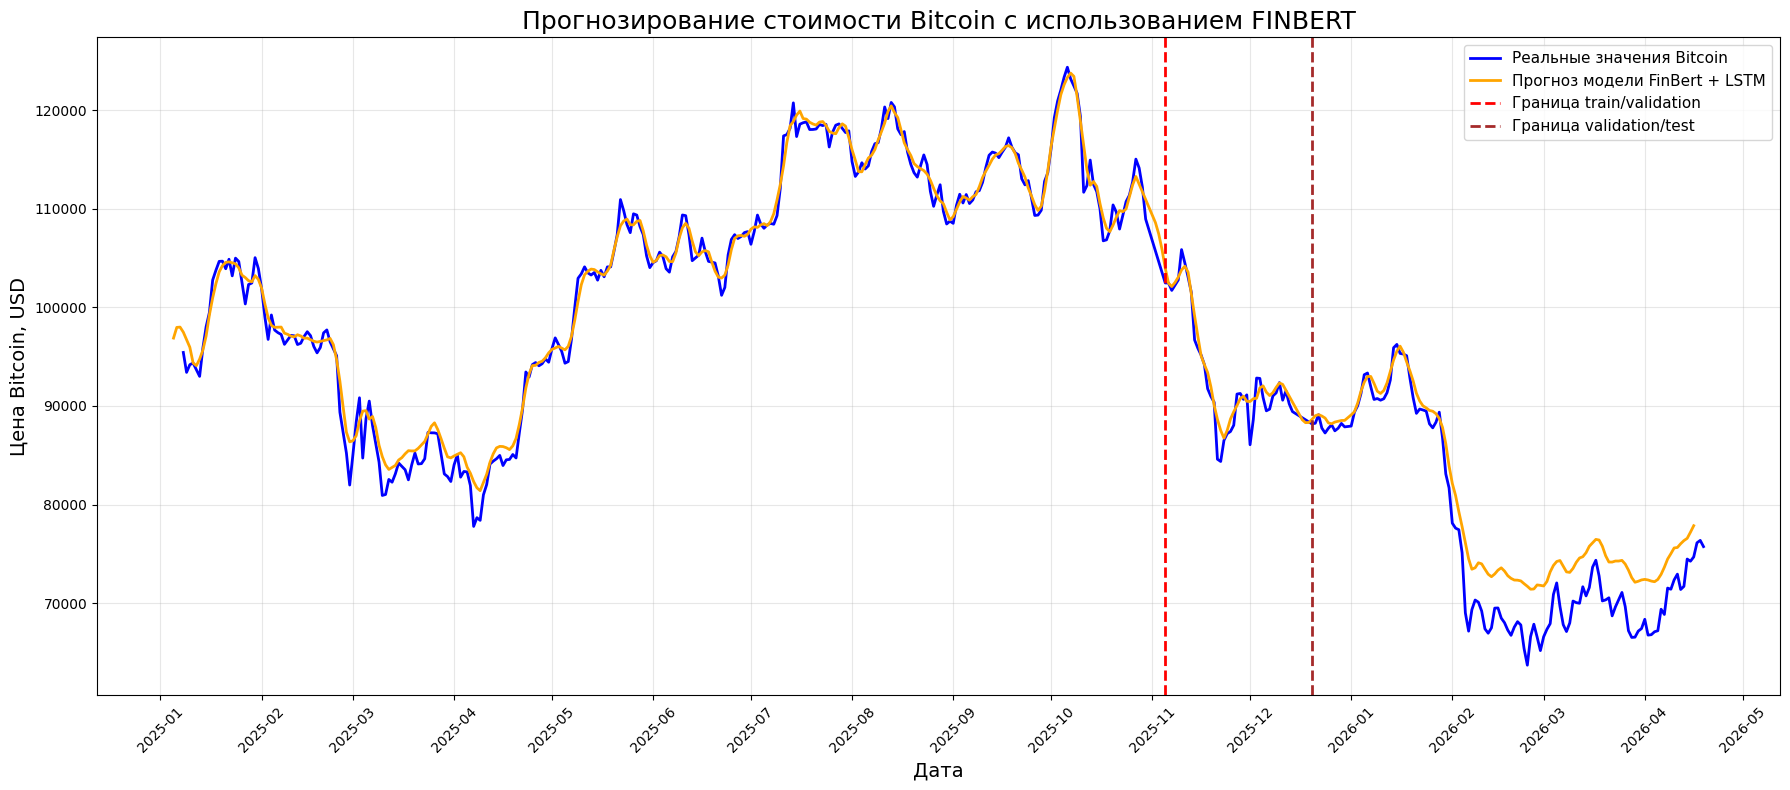

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

train_prediction_bert = model_bert.predict(X_train_bert)

# Добавляем sentiment обратно для inverse_transform
train_full = np.concatenate(
    (
        train_prediction_bert,
        X_train_bert[:, -1, 1].reshape(-1, 1)
    ),
    axis=1
)

train_prediction_inverse = scaler.inverse_transform(
    train_full
)[:, 0]

# Реальные значения train

train_real_full = np.concatenate(
    (
        Y_train_bert.reshape(-1, 1),
        X_train_bert[:, -1, 1].reshape(-1, 1)
    ),
    axis=1
)

Y_train_inverse = scaler.inverse_transform(train_real_full)[:, 0]

val_prediction_bert = model_bert.predict(X_val_bert)

val_full = np.concatenate(
    (
        val_prediction_bert,
        X_val_bert[:, -1, 1].reshape(-1, 1)
    ),
    axis=1
)

val_prediction_inverse = scaler.inverse_transform(
    val_full
)[:, 0]

# Реальные validation значения

val_real_full = np.concatenate(
    (
        Y_val_bert.reshape(-1, 1),
        X_val_bert[:, -1, 1].reshape(-1, 1)
    ),
    axis=1
)

Y_val_inverse = scaler.inverse_transform(
    val_real_full
)[:, 0]

# =====================================================
# ПРЕДСКАЗАНИЯ TEST
# =====================================================

test_prediction_bert = model_bert.predict(
    X_test_bert
)

test_full = np.concatenate(
    (
        test_prediction_bert,
        X_test_bert[:, -1, 1].reshape(-1, 1)
    ),
    axis=1
)

test_prediction_inverse = scaler.inverse_transform(test_full)[:, 0]

# Реальные test значения

test_real_full = np.concatenate(
    (
        Y_test_bert.reshape(-1, 1),
        X_test_bert[:, -1, 1].reshape(-1, 1)
    ),
    axis=1
)

Y_test_inverse = scaler.inverse_transform(test_real_full)[:, 0]

# =====================================================
# ДАТЫ
# =====================================================

train_dates_plot = pd.to_datetime(
    df_bert_train['date'].iloc[look_back:]
).reset_index(drop=True)

val_dates_plot = pd.to_datetime(
    val_bert_df['date'].iloc[look_back:]
).reset_index(drop=True)

test_dates_plot = pd.to_datetime(
    df_bert_test['date'].iloc[look_back:]
).reset_index(drop=True)

# =====================================================
# ВЫРАВНИВАНИЕ РАЗМЕРОВ
# =====================================================

min_train = min(
    len(train_dates_plot),
    len(Y_train_inverse),
    len(train_prediction_inverse)
)

train_dates_plot = train_dates_plot[:min_train]
Y_train_inverse = Y_train_inverse[:min_train]
train_prediction_inverse = train_prediction_inverse[:min_train]

# -----------------------------

min_val = min(
    len(val_dates_plot),
    len(Y_val_inverse),
    len(val_prediction_inverse)
)

val_dates_plot = val_dates_plot[:min_val]
Y_val_inverse = Y_val_inverse[:min_val]
val_prediction_inverse = val_prediction_inverse[:min_val]

# -----------------------------

min_test = min(
    len(test_dates_plot),
    len(Y_test_inverse),
    len(test_prediction_inverse)
)

test_dates_plot = test_dates_plot[:min_test]
Y_test_inverse = Y_test_inverse[:min_test]
test_prediction_inverse = test_prediction_inverse[:min_test]

# =====================================================
# ОБЪЕДИНЕНИЕ ДАННЫХ
# =====================================================

all_real_dates = pd.concat([
    train_dates_plot,
    val_dates_plot,
    test_dates_plot
])

all_real_values = np.concatenate([
    Y_train_inverse,
    Y_val_inverse,
    Y_test_inverse
])

# -----------------------------

all_pred_dates = pd.concat([
    train_dates_plot,
    val_dates_plot,
    test_dates_plot
])

all_pred_values_bert = np.concatenate([
    train_prediction_inverse,
    val_prediction_inverse,
    test_prediction_inverse
])

# =====================================================
# ГРАФИК
# =====================================================

plt.figure(figsize=(18, 8))

# Реальные значения

plt.plot(
    all_real_dates,
    all_real_values,
    label='Реальные значения Bitcoin',
    color='blue',
    linewidth=2
)

# Предсказания

plt.plot(
    all_pred_dates,
    all_pred_values_bert,
    label='Прогноз модели FinBert + LSTM',
    color='orange',
    linewidth=2
)

# =====================================================
# ГРАНИЦЫ ВЫБОРОК
# =====================================================

plt.axvline(
    x=val_dates_plot.iloc[0],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Граница train/validation'
)

plt.axvline(
    x=test_dates_plot.iloc[0],
    color='brown',
    linestyle='--',
    linewidth=2,
    label='Граница validation/test'
)

# =====================================================
# ОФОРМЛЕНИЕ
# =====================================================

plt.title(
    'Прогнозирование стоимости Bitcoin с использованием FINBERT',
    fontsize=18
)

plt.xlabel(
    'Дата',
    fontsize=14
)

plt.ylabel(
    'Цена Bitcoin, USD',
    fontsize=14
)

# Форматирование оси X

ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

train_prediction_inverse_bert = train_prediction_inverse
val_prediction_inverse_bert = val_prediction_inverse
test_prediction_inverse_bert = test_prediction_inverse

# Все вместе

In [ ]:
all_pred_values_lstm = all_pred_values_lstm[20:]

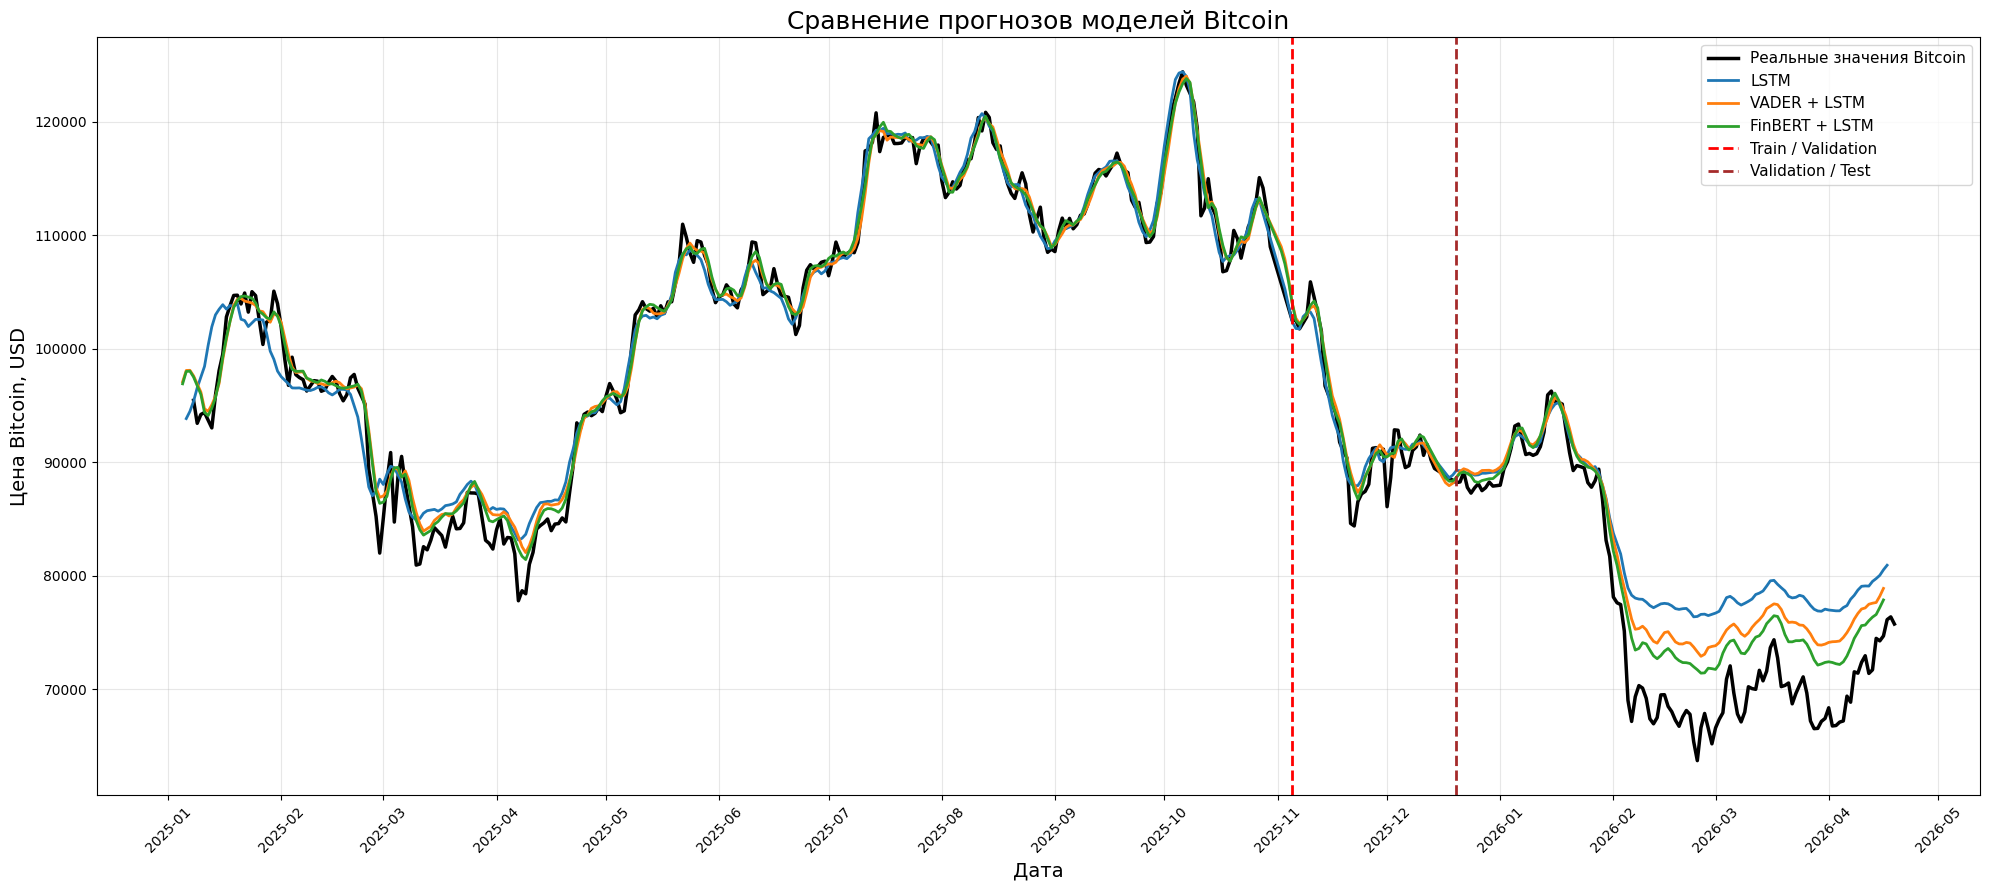

In [ ]:
plt.figure(figsize=(20, 9))

# Реальные значения
plt.plot(
    all_real_dates,
    all_real_values,
    label='Реальные значения Bitcoin',
    color='black',
    linewidth=2.5
)

# LSTM
plt.plot(
    all_pred_dates,
    all_pred_values_lstm,
    label='LSTM',
    linewidth=2
)

# VADER + LSTM
plt.plot(
    all_pred_dates,
    all_pred_values_vader,
    label='VADER + LSTM',
    linewidth=2
)

# FinBERT + LSTM
plt.plot(
    all_pred_dates,
    all_pred_values_bert,
    label='FinBERT + LSTM',
    linewidth=2
)

# Границы выборок
plt.axvline(
    x=val_dates_plot.iloc[0],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Train / Validation'
)

plt.axvline(
    x=test_dates_plot.iloc[0],
    color='brown',
    linestyle='--',
    linewidth=2,
    label='Validation / Test'
)

plt.title(
    'Сравнение прогнозов моделей Bitcoin',
    fontsize=18
)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена Bitcoin, USD', fontsize=14)

ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()

In [ ]:
all_real_dates = all_real_dates[200:]
all_real_values = all_real_values[200:]
all_pred_values_lstm = all_pred_values_lstm[200:]
all_pred_values_vader = all_pred_values_vader[200:]
all_pred_values_bert = all_pred_values_bert[200:]
all_pred_dates = all_pred_dates[200:]

In [ ]:
print(len(all_pred_dates))
print(len(all_pred_values_lstm))
print(len(all_pred_values_vader))
print(len(all_pred_values_bert))

251
251
251
251


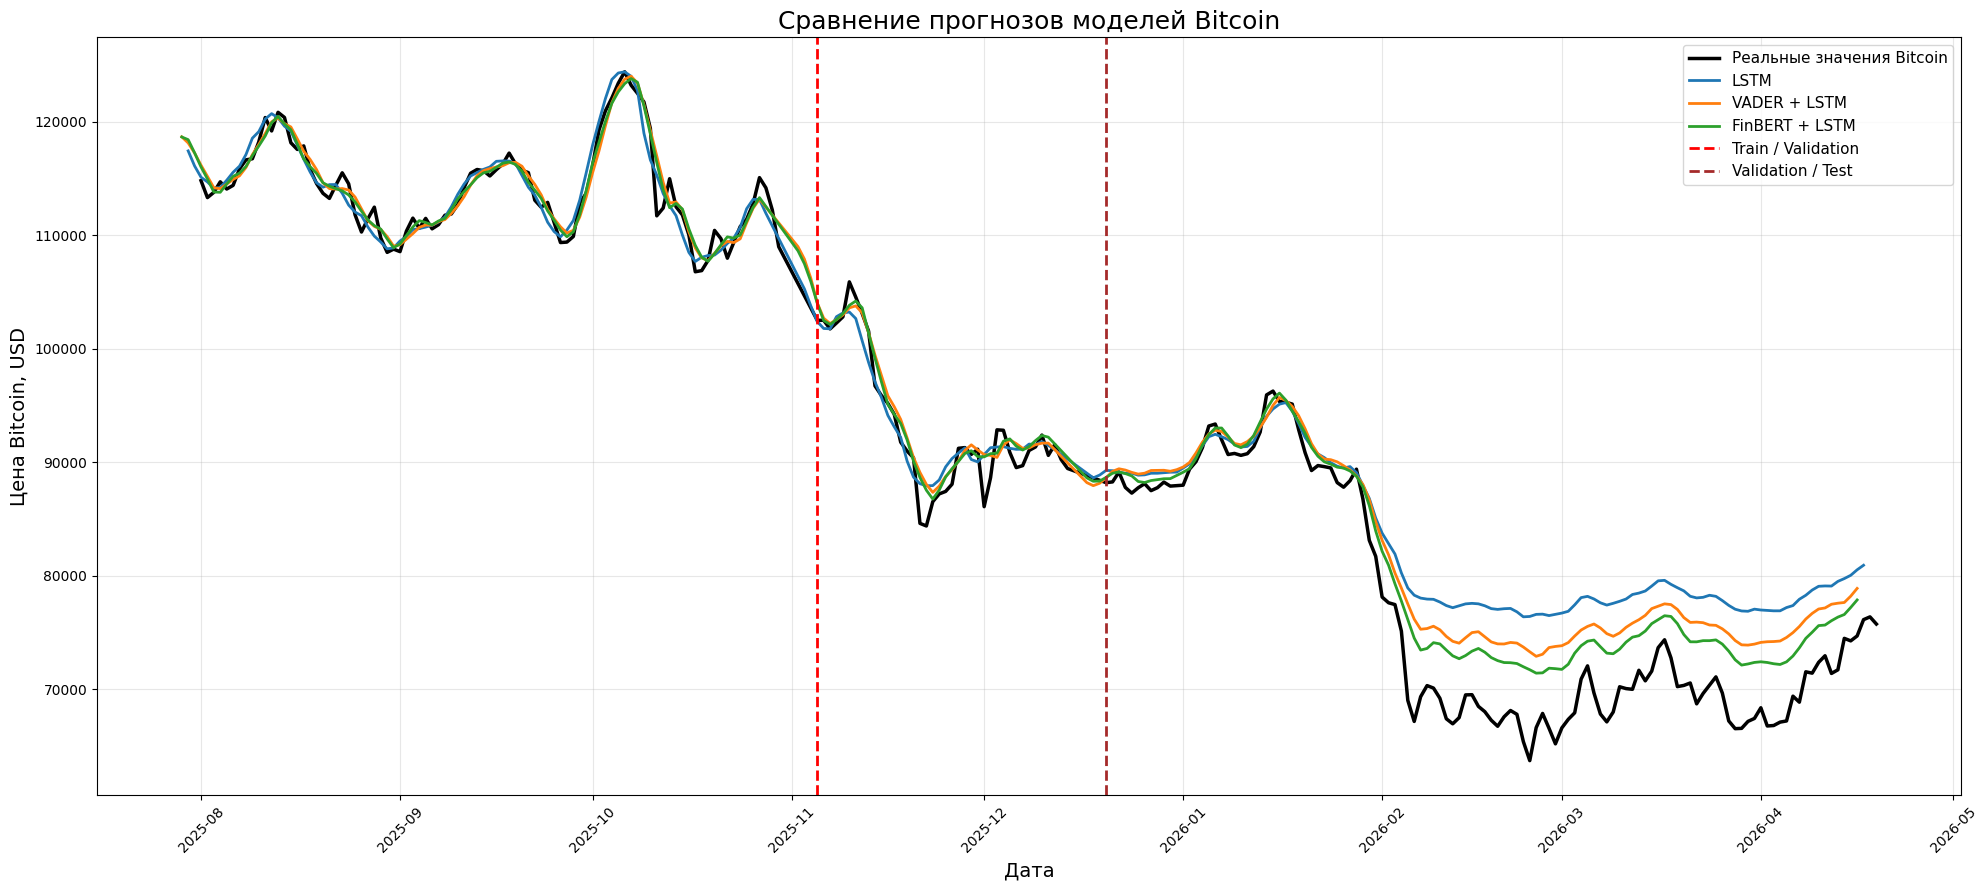

In [ ]:
plt.figure(figsize=(20, 9))

# Реальные значения
plt.plot(
    all_real_dates,
    all_real_values,
    label='Реальные значения Bitcoin',
    color='black',
    linewidth=2.5
)

# LSTM
plt.plot(
    all_pred_dates,
    all_pred_values_lstm,
    label='LSTM',
    linewidth=2
)

# VADER + LSTM
plt.plot(
    all_pred_dates,
    all_pred_values_vader,
    label='VADER + LSTM',
    linewidth=2
)

# FinBERT + LSTM
plt.plot(
    all_pred_dates,
    all_pred_values_bert,
    label='FinBERT + LSTM',
    linewidth=2
)

# Границы выборок
plt.axvline(
    x=val_dates_plot.iloc[0],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Train / Validation'
)

plt.axvline(
    x=test_dates_plot.iloc[0],
    color='brown',
    linestyle='--',
    linewidth=2,
    label='Validation / Test'
)

plt.title(
    'Сравнение прогнозов моделей Bitcoin',
    fontsize=18
)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена Bitcoin, USD', fontsize=14)

ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()